Now that we have shown that the k-fold models generalize better to the test data than a random baseline, we will generate a new model with the best hyperparameters identified, but trained on the training + validation data. This is simply to have one coherent model for additional downstream assessments. It also should give the model better power.

In [1]:
import os

import pandas as pd
import scanpy as sc

import torch
import torch.nn as nn
import numpy as np
from geomloss import SamplesLoss
from sklearn.metrics import normalized_mutual_info_score
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../.')
from Kang_utils import get_best_hyperparams


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSC
from scLEMBAS.preprocess import discriminator_weight_curve, embed_tf_activity

In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')

In [4]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

# ensures correct order of test data
# note, this already saved in order, matching the mod.y_out columns
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data

In [5]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [6]:
data_split_path = os.path.join(os.path.join(data_path, 'processed', 'data_split_barcodes'))
fold_keys = ['train_cells', 'val_cells', 'train_cond', 'val_cond']
k_fold_cells = {}
for k in range(5):
    k_fold_cells[k] = {fk: open(os.path.join(data_split_path, 'kang_' + str(k) + '_' + fk + '.txt')).read().splitlines()
                      for fk in fold_keys}
    

In [7]:
# subset to run quicker
k = 0

fraction = 0.25  
n_total = int(len(tf_adata.obs) * fraction)  
category_counts = tf_adata.obs['condition'].value_counts(normalize=True)  
subset_counts = (category_counts * n_total).round().astype(int)
subset_df = pd.concat([
    tf_adata.obs[tf_adata.obs['condition'] == category].sample(n=count, random_state=42)
    for category, count in subset_counts.items()
])
train_cells = subset_df[subset_df['condition'].isin(k_fold_cells[k]['train_cond'])].index.tolist()
test_cells = k_fold_cells[k]['val_cells']
val_cells = test_cells


### Params

In [8]:
def generate_lr_params(n_epochs, max_lr, lr_scaling_factor = 10, lr_decay = 0.9):
    lr_period = 3 if n_epochs < 500 else 4
    lr_params = {'max_epochs': n_epochs, 
                 'maximum_learning_rate': max_lr, 
                 'minimum_learning_rate': max_lr/lr_scaling_factor,
                 'lr_restart_epoch': int(n_epochs/lr_period), 
                 'reset_optimizer_epoch': int(n_epochs/3), 
                'lr_decay': lr_decay, 
                 'lr_restart_factor': 1, 
                 'warmup_epochs': int(n_epochs/10)}
    return lr_params

def generate_discriminator_params(n_epochs, max_lr, discriminator_penalty_weight, 
                                  lr_scaling_factor = 10, lr_decay = 0.9):
    general_params = generate_lr_params(n_epochs, max_lr, lr_scaling_factor = lr_scaling_factor, 
                                        lr_decay = lr_decay)
    
    keys_to_keep = ['maximum_learning_rate', 'minimum_learning_rate', 'lr_restart_epoch', 
                   'warmup_epochs', 'lr_decay', 'reset_optimizer_epoch']
    discriminator_params = {'batch_momentum': 0.01,
                            'layer_norm': False,
                            'dropout_rate': 0.1,
                            'activation_fn': nn.LeakyReLU,
                            'n_hidden_nodes': [768, 512, 256],
                            'lr_restart_factor': 1,
                            'optimizer': torch.optim.Adam,
                            'discriminator_lambda_L2': 1e-3,
                            'discriminator_penalty_weight': discriminator_penalty_weight}
    discriminator_params = {**discriminator_params, 
                           **{k:v for k,v in general_params.items() if k in keys_to_keep}}
    
    return discriminator_params

In [9]:
# vae
n_layers_vae = 2
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

# linear scaling of inputs/outputs
projection_amplitude_in = 1
projection_amplitude_out = 1

# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 100 # 1 
                } 
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}

# training parameters
other_params_default = {'network_noise_scale': 10, 'gradient_noise_scale': 1e-9, 
               'test_batch_size': np.nan}
spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, #50, 
                          'subset_n_spectral': 5} #10}
target_spectral_radius = 0.9

regularization_params_default = {'input_lambda_L2': 0, # doesn't matter if setting the requires grad to False
                         'bn_weights_lambda_l2': 1e-7, 
                         'bn_bias_lambda_L2': 0, # don't incorporate because of KL divergence
                         'output_weights_lambda_L2': 1e-7,
                         'output_bias_lambda_L2': 1e-7,
                         'moa_lambda_L1': 1e2,  
                         'uniform_lambda_L2': 1e-7,#, 1e-5,
                         'uniform_min': 0,
                         'uniform_max': 1, 
                         'spectral_loss_factor': 1e-6,
                        'vae_lambda_l2': 1e-7, 
                        'vae_scaling_KL': 1e-2}

In [10]:
max_epochs = 900 #50
train_batch = 256 #int(len(train_cells)/2)
max_lr = 0.001

In [11]:
# discriminator_penalty_weight, _ = discriminator_weight_curve(n_epochs = max_epochs,
#                                                                min_penalty_weight = 0.1,
#                                                                max_penalty_weight = 4, 
#                                                               a = 1, 
#                                                               b = 0.007, 
#                                                                   curve_type = 'exponential')

frac_no_adv = 0 # allow discriminator to fully learn the first fraction of epochs
n_no_adv = int(max_epochs*frac_no_adv)
min_penalty_weight = 0.1
discriminator_penalty_weight = [min_penalty_weight/10]*n_no_adv
discriminator_penalty_weight += discriminator_weight_curve(n_epochs = max_epochs - n_no_adv,
                                                               min_penalty_weight = min_penalty_weight,
                                                               max_penalty_weight = 4, 
                                                              a = 1, 
                                                              b = 0.4, 
                                                                  curve_type = 'power')
# discriminator_penalty_weight += discriminator_weight_curve(n_epochs = max_epochs - n_no_adv,
#                                                                min_penalty_weight = min_penalty_weight,
#                                                                max_penalty_weight = 5, # 4 
#                                                               a = 1, 
#                                                               b = 0.6, 
#                                                                   curve_type = 'power')


lr_params = generate_lr_params(n_epochs = max_epochs, max_lr = max_lr, lr_scaling_factor = 10, lr_decay = 0.9)
discriminator_params = generate_discriminator_params(n_epochs = max_epochs, max_lr = max_lr, 
                      discriminator_penalty_weight = discriminator_penalty_weight, 
                      lr_scaling_factor = 10, lr_decay = 0.9)
# tune other parameters as a function of those being adjusted
regularization_params = regularization_params_default.copy()
other_params = {**other_params_default,
                **{'train_batch_size': train_batch,
                   'validation_batch_size': len(val_cells)}}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}


<Axes: >

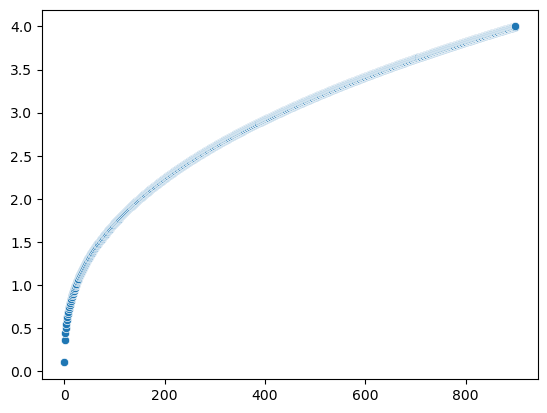

In [12]:
fig, ax = plt.subplots()
sns.scatterplot(x = list(range(len(discriminator_penalty_weight))), 
               y = discriminator_penalty_weight, 
               ax = ax)

### Train

In [13]:
mod = SignalingModel(net = sn_ppis,
                     X_in = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1']),
                     y_out = tf_adata.to_df().copy(), 
                     expr = adata.to_df().copy(), 
                     covariates = tf_adata.obs.copy(),
                     categorical_covariate_keys = ['seurat_annotations'],
                     projection_amplitude_in = projection_amplitude_in, 
                     projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainSC(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': train_cells, 'test': None, 'validation': val_cells}, 
                   train_seed = seed, 
                   track_test = False,
                   track_validation = False)
mod = trainer.train_model(verbose = False)
torch.cuda.empty_cache()

100%|█████████████████████████████████████████| 900/900 [48:21<00:00,  3.22s/it]


In [14]:
# noadverserial_params = discriminator_params.copy()
# noadverserial_params['discriminator_penalty_weight'] = min(noadverserial_params['discriminator_penalty_weight'])

# mod_na = SignalingModel(net = sn_ppis,
#                      X_in = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1']),
#                      y_out = tf_adata.to_df().copy(), 
#                      expr = adata.to_df().copy(), 
#                      covariates = tf_adata.obs.copy(),
#                      categorical_covariate_keys = ['seurat_annotations'],
#                      projection_amplitude_in = projection_amplitude_in, 
#                      projection_amplitude_out = projection_amplitude_out,
#                      weight_label = weight_label, source_label = source_label, target_label = target_label,
#                      bionet_params = bionet_params, 
#                      dtype = torch.float32, device = device, seed = seed)
# # mod_nael setup
# mod_na.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
# mod_na.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# # training loop
# trainer_na = TrainSC(mod = mod_na,
#                    prediction_optimizer = torch.optim.Adam,
#                    prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
#                   discriminator_params = noadverserial_params,
#                    hyper_params = training_params,
#                    train_split = {'train': train_cells, 'test': None, 'validation': val_cells}, 
#                    train_seed = seed, 
#                    track_test = False,
#                    track_validation = False)
# mod_na = trainer_na.train_model(verbose = False)
# torch.cuda.empty_cache()

### Loss

In [15]:
train_stats_df = trainer.stats['train'].copy()
train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() 

# train_stats_df_na = trainer_na.stats['train'].copy()
# train_stats_df_na = train_stats_df_na.groupby('epoch').mean().reset_index() # delete this

/tmp/ipykernel_185742/3327071032.py:34: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
/tmp/ipykernel_185742/3327071032.py:60: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])


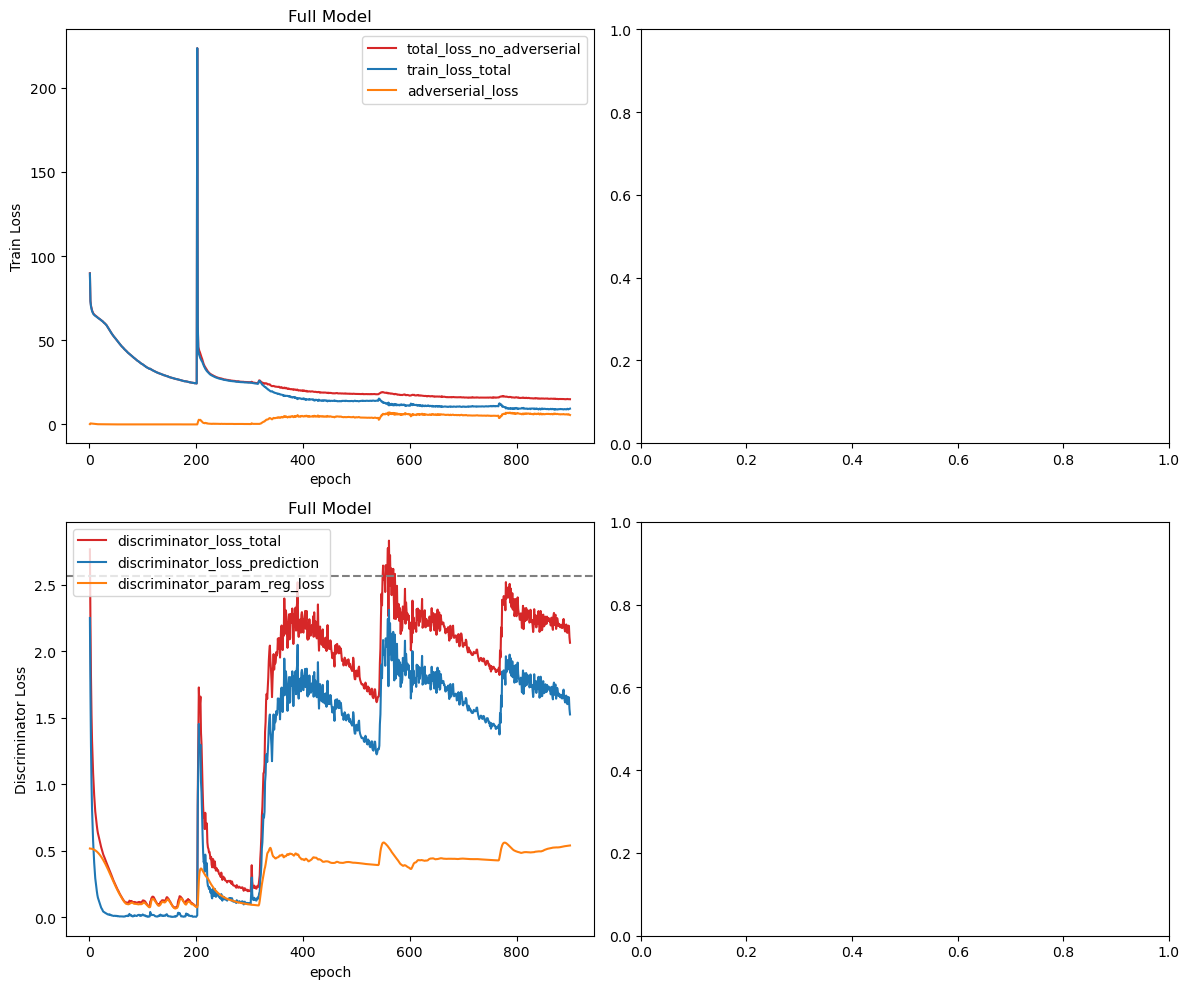

In [16]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,10))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# Plot 1: full model, adverserial loss
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']
loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
ax[0].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[0].set_ylabel('Train Loss')
ax[0].set_title('Full Model')

# # Plot 2: model no adverserial, adverserial loss
# viz_df = train_stats_df_na[['epoch'] + loss_cols].copy()
# viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
# viz_df.drop(columns = loss_cols_main, inplace = True)
# viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
# viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

# sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
# ax[1].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
# ax[1].set_ylabel('Train Loss')
# ax[1].set_title('No Adverserial Model')


# Plot 3: full model, discriminator loss
loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])
n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
ax[2].axhline(y=np.log(n_cat), color='gray', linestyle='--')

ax[2].legend(loc='best')
ax[2].set_ylabel('Discriminator Loss')
ax[2].set_title('Full Model')

# # Plot 4: model no adverserial, discriminator loss
# viz_df = train_stats_df_na[['epoch'] + loss_cols_disc].copy()
# viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
# viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

# sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[3])
# n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
# ax[3].axhline(y=np.log(n_cat), color='gray', linestyle='--')

# ax[3].legend(loc='best')
# ax[3].set_ylabel('Discriminator Loss')
# ax[3].set_title('No Adverserial Model')


fig.tight_layout()

## Test Data

### Predict

In [17]:
stim_map = {'STIM': 1, 'CTRL': 0}
rev_stim = {'STIM': 'CTRL', 'CTRL': 'STIM'}
# rev_stim_map = {k: int(not bool(v)) for k,v in stim_map.items()}

cov_idx_map = dict(zip(mod.signaling_network.covariates['seurat_annotations'], 
                       mod.signaling_network.covariates_idx['seurat_annotations']))
cov_rev_map = {v:k for k,v in cov_idx_map.items()}

In [18]:
only_within_celltype = True # only change stim within a cell type
full_expr, full_X, full_covariates = None, None, None

for cond in tf_adata.obs.loc[test_cells, :].condition.unique():
    stim, ct = cond.split('^')

    if only_within_celltype:
        train_cells_cond = tf_adata.obs[(tf_adata.obs.index.isin(train_cells)) & 
                                        (tf_adata.obs['condition'] == rev_stim[stim] + '^' + ct)].index.tolist()
    else:
        train_cells_cond = train_cells
    
    expr_test = mod.df_to_tensor(mod.expr.loc[train_cells_cond, :])

    X_test_df = pd.DataFrame(data = {'IFNB1': [stim_map[stim]]*len(train_cells_cond)})
    X_test = mod.df_to_tensor(X_test_df)

    covariates_idx_test = torch.tensor([cov_idx_map[ct]]*len(train_cells_cond), 
                                       device = mod.device, dtype = torch.int64).view(-1,1)
    
    if full_expr is None:
        full_expr = expr_test
    else: 
        full_expr = torch.cat((full_expr, expr_test), dim = 0)
        
    if full_X is None:
        full_X = X_test
    else: 
        full_X = torch.cat((full_X, X_test), dim = 0)

    if full_covariates is None:
        full_covariates = covariates_idx_test
    else: 
        full_covariates = torch.cat((full_covariates, covariates_idx_test), dim = 0)    

In [19]:
# mod_na.eval()
# with torch.inference_mode():
#     y_predicted, Y_full, biases = mod_na(X_in = full_X, covariates_idx = full_covariates, expr = full_expr)
#     bias_global_na, bias_mu, bias_log_sigma_squared = biases 

mod.eval()
with torch.inference_mode():
    y_predicted, Y_full, biases = mod(X_in = full_X, covariates_idx = full_covariates, expr = full_expr)
    bias_global, bias_mu, bias_log_sigma_squared = biases
    bias_sigma = torch.exp(bias_log_sigma_squared/2.) + mod.signaling_network.vae.var_min

mod.eval()
with torch.inference_mode():
    bias_cats = torch.zeros_like(bias_global.T, device = mod.device, dtype = mod.dtype)
    for cat_group_idx in range(full_covariates.shape[1]):
        cat_group = mod.signaling_network._cat_group_idx[cat_group_idx]
        mod.signaling_network.cat_embeddings[cat_group].weight.data.masked_fill_(mask = mod.signaling_network.cat_embeddings_mask[cat_group], 
                                                                    value = 0.0)
        bias_cats += mod.signaling_network.cat_embeddings[cat_group](full_covariates[:,cat_group_idx]).T
    bias_tot = bias_global.T + bias_cats    
    

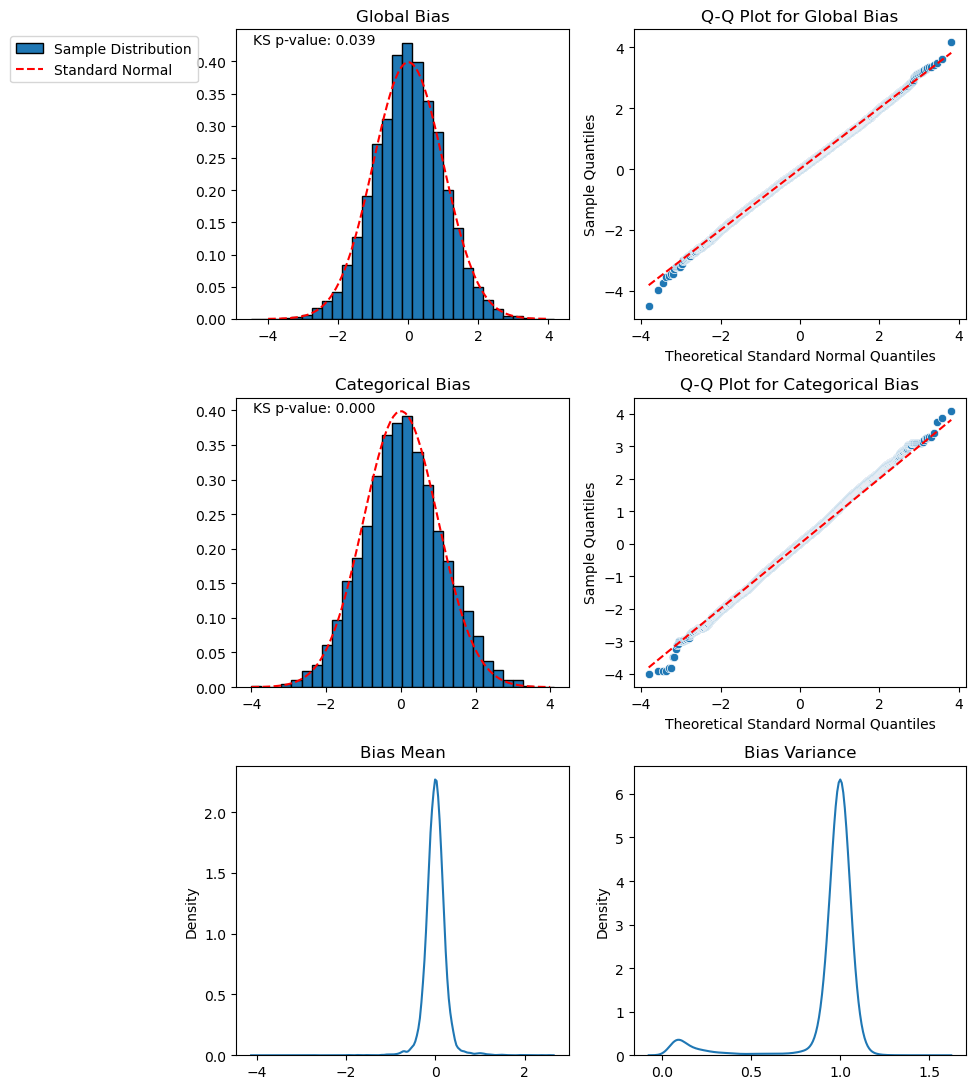

In [20]:
fig, ax = plt.subplots(ncols = 2, nrows = 3, figsize = (10, 11))
ax = ax.flatten()

i = 0
bias_viz = bias_global.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)

counts, bins = np.histogram(bias_viz_sub, bins=30, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
          color=sns.color_palette()[0], edgecolor = 'black', label="Sample Distribution")
# sns.histplot(bias_viz_sub, ax = ax[i])

x = np.linspace(-4, 4, 100)
sn, = ax[i].plot(x, stats.norm.pdf(x), 'r--', label="Standard Normal")

ax[i].legend(handles=[hist, sn], labels=["Sample Distribution", "Standard Normal"], 
            loc='upper left', bbox_to_anchor=(-0.7, 1))


ks_statistic, pval = stats.kstest(bias_viz_sub, 'norm')
ax[i].annotate('KS p-value: {:.3f}'.format(pval), 
              xy=(0.05, 0.95), 
            xycoords="axes fraction",
            ha="left")
ax[i].set_title('Global Bias')


i+=1
(q_theoretical, q_sample), _ = stats.probplot(bias_viz_sub, dist="norm")
qq_df = pd.DataFrame({"Theoretical Standard Normal Quantiles": q_theoretical, "Sample Quantiles": q_sample})
sns.scatterplot(data=qq_df, x="Theoretical Standard Normal Quantiles", y="Sample Quantiles", ax = ax[i])
sns.lineplot(x=q_theoretical, y=q_theoretical, color="red", linestyle="--", ax = ax[i])  # 45-degree reference line
ax[i].set_title('Q-Q Plot for Global Bias')

i+=1
bias_viz = bias_cats.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)

counts, bins = np.histogram(bias_viz_sub, bins=30, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
hist = ax[i].bar(bin_centers, counts, width=(bins[1] - bins[0]), 
          color=sns.color_palette()[0], edgecolor = 'black', label="Sample Distribution")
# sns.histplot(bias_viz_sub, ax = ax[i])

x = np.linspace(-4, 4, 100)
sn, = ax[i].plot(x, stats.norm.pdf(x), 'r--', label="Standard Normal")

# ax[i].legend(handles=[hist, sn], labels=["Sample Distribution", "Standard Normal"], 
#             loc='upper left', bbox_to_anchor=(-0.75, 1))


ks_statistic, pval = stats.kstest(bias_viz_sub, 'norm')
ax[i].annotate('KS p-value: {:.3f}'.format(pval), 
              xy=(0.05, 0.95), 
            xycoords="axes fraction",
            ha="left")
ax[i].set_title('Categorical Bias')

i+=1
(q_theoretical, q_sample), _ = stats.probplot(bias_viz_sub, dist="norm")
qq_df = pd.DataFrame({"Theoretical Standard Normal Quantiles": q_theoretical, "Sample Quantiles": q_sample})
sns.scatterplot(data=qq_df, x="Theoretical Standard Normal Quantiles", y="Sample Quantiles", ax = ax[i])
sns.lineplot(x=q_theoretical, y=q_theoretical, color="red", linestyle="--", ax = ax[i])  # 45-degree reference line
ax[i].set_title('Q-Q Plot for Categorical Bias')


i+=1
bias_viz = bias_mu.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)
sns.kdeplot(bias_viz_sub, ax = ax[i])
ax[i].set_title('Bias Mean')


i+=1
bias_viz = bias_sigma.detach().cpu().numpy().flatten()
np.random.seed(seed)
bias_viz_sub = np.random.choice(bias_viz, size = int(1e4), replace = False)
sns.kdeplot(bias_viz_sub, ax = ax[i])
ax[i].set_title('Bias Variance')

fig.tight_layout()

### Assess

In [21]:
print('Adverserially trained loss on test:')
discriminator = trainer.discriminator['discriminators']['seurat_annotations']
loss_fn = nn.CrossEntropyLoss()

discriminator.eval()
with torch.inference_mode():
    discriminator_prediction = discriminator(bias_global)
    loss = loss_fn(discriminator_prediction, full_covariates.view(-1))
loss

Adverserially trained loss on test:


tensor(1.7480, device='cuda:0')

In [22]:
# print('Not adverserially trained loss on test:')

# discriminator = trainer_na.discriminator['discriminators']['seurat_annotations']
# loss_fn = nn.CrossEntropyLoss()

# discriminator.eval()
# with torch.inference_mode():
#     discriminator_prediction = discriminator(bias_global_na)
#     loss = loss_fn(discriminator_prediction, full_covariates.view(-1))
# loss

In [23]:
# subset for quicker computation
df = pd.DataFrame(full_covariates.detach().cpu().numpy(), columns = ['category_column'])
fraction = 0.25  
n_total = int(len(df) * fraction) 
category_counts = df['category_column'].value_counts(normalize=True)  
subset_counts = (category_counts * n_total).round().astype(int)
subset_df = pd.concat([
    df[df['category_column'] == category].sample(n=count, random_state=42)
    for category, count in subset_counts.items()
])

full_covariates = full_covariates.detach().cpu().numpy()[subset_df.index, :]
bias_global = bias_global.detach().cpu().numpy()[subset_df.index, :]
# bias_global_na = bias_global_na.detach().cpu().numpy()[subset_df.index, :]
bias_tot = bias_tot.detach().cpu().numpy().T[subset_df.index, :]

In [24]:
obs = pd.DataFrame(full_covariates)
obs.columns = ['seurat_annotations']
obs.seurat_annotations = obs.seurat_annotations.map(cov_rev_map)

# # perfect
# onehot_df = pd.get_dummies(obs.seurat_annotations).astype(int)
# one_hot = sc.AnnData(X = onehot_df, obs = obs)
# embed_tf_activity(one_hot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
#                  n_components = one_hot.shape[1] - 1)
# # perfectly random
# np.random.seed(seed)
# rand_idx = np.random.permutation(onehot_df.index)
# rand_obs = obs.copy()
# rand_obs.index = rand_idx
# rand = sc.AnnData(X = onehot_df.loc[rand_idx, :], obs = rand_obs)
# embed_tf_activity(rand, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
#                  n_components = rand.shape[1] - 1)

# # no adverserial
# bias_adata_na = sc.AnnData(X = bias_global_na, obs = obs)
# embed_tf_activity(bias_adata_na, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

# full model
bias_adata = sc.AnnData(X = bias_global, obs = obs)
embed_tf_activity(bias_adata, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

# full model -- categorical information added
bias_tot = sc.AnnData(X = bias_tot, obs = obs)
embed_tf_activity(bias_tot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/preprocess.py:290: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata = tf_adata, resolution = resolution) # cluster
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS

In [25]:
def adata_dimviz(adata, reduction_type, cat, subset_idx = None):
    viz_df = pd.DataFrame(adata.obsm['X_' + reduction_type])
    viz_df = pd.concat([viz_df, pd.DataFrame(adata.obs[cat]).reset_index(drop = True)], ignore_index = True, axis = 1)

    viz_df.columns = [reduction_type.upper() + str(i+1) for i in range(viz_df.shape[1])]
    viz_df.columns = viz_df.columns[:-1].tolist() + [cat]
    
    if subset_idx is not None:
        viz_df = viz_df.loc[subset_idx, :]
    
    return viz_df

In [26]:
# adata_types = ['Model No Adverserial', 'Model with Adverserial', 
#                'Model with Adverserial - Categorical Information Added']
# adata_dict = dict(zip(adata_types, 
#                      [bias_adata_na, bias_adata, bias_tot]))


adata_types = ['Model with Adverserial', 
               'Model with Adverserial - Categorical Information Added']
adata_dict = dict(zip(adata_types, 
                     [bias_adata, bias_tot]))

''

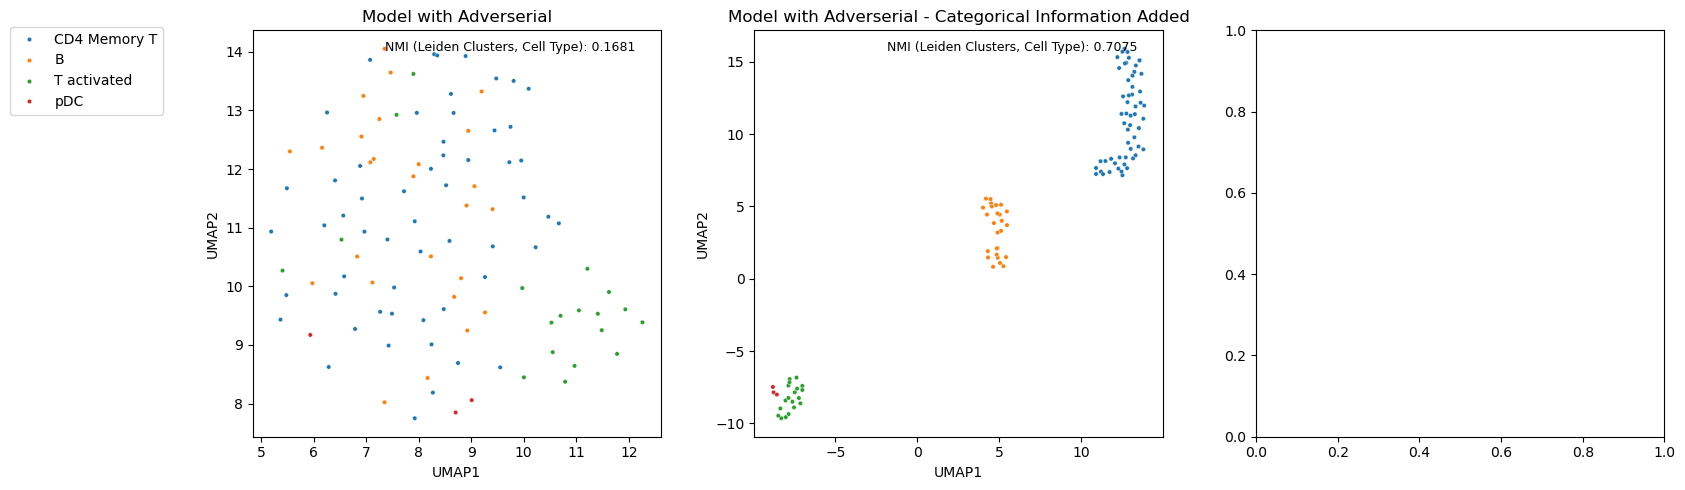

In [27]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))
ax = ax.flatten()

# subset_size = 5000
# subset_cells = np.random.choice(list(range(y_predicted.shape[0])), size=subset_size, replace=False)

for i, (adata_type, adata) in enumerate(adata_dict.items()):
    viz_df = adata_dimviz(adata = adata, reduction_type = 'umap', cat = 'seurat_annotations', 
                         subset_idx = None)
    nmi = normalized_mutual_info_score(adata.obs.leiden, adata.obs.seurat_annotations)

    sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'seurat_annotations', 
                    s=10,
                    ax = ax[i])
    ax[i].annotate('NMI (Leiden Clusters, Cell Type): {:.4f}'.format(nmi),
                    xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
    ax[i].set_title(adata_type)

lines, labels = ax[1].get_legend_handles_labels()
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(-0.125, 0.95))
for ax_ in ax:
    ax_.legend().remove()
    
    
fig.tight_layout()
;

## Train Data

In [ ]:
expr_test = mod.df_to_tensor(mod.expr.loc[train_cells, :])
X_test = mod.df_to_tensor(mod.X_in.loc[train_cells, :])
covariates_test = torch.tensor(mod.signaling_network.covariates_idx.loc[train_cells,:].values, 
             device = device, dtype = torch.int64)

### Predict

In [ ]:
mod_na.eval()
with torch.inference_mode():
    _, _, biases = mod_na(X_in = X_test, covariates_idx = covariates_test, expr = expr_test)
    bias_global_na, _, _ = biases 

mod.eval()
with torch.inference_mode():
    _, _, biases = mod(X_in = X_test, covariates_idx = covariates_test, expr = expr_test)
    bias_global, _, _ = biases

In [ ]:
print('Adverserially trained loss on train:')
discriminator = trainer.discriminator['discriminators']['seurat_annotations']
loss_fn = nn.CrossEntropyLoss()

discriminator.eval()
with torch.inference_mode():
    discriminator_prediction = discriminator(bias_global)
    loss = loss_fn(discriminator_prediction, covariates_test.view(-1))
loss

In [ ]:
print('Not adverserially trained loss on train:')

discriminator = trainer_na.discriminator['discriminators']['seurat_annotations']
loss_fn = nn.CrossEntropyLoss()

discriminator.eval()
with torch.inference_mode():
    discriminator_prediction = discriminator(bias_global_na)
    loss = loss_fn(discriminator_prediction, covariates_test.view(-1))
loss

In [ ]:
obs = pd.DataFrame(covariates_test.detach().cpu().numpy())
obs.columns = ['seurat_annotations']
obs.seurat_annotations = obs.seurat_annotations.map(cov_rev_map)

# # perfect
# onehot_df = pd.get_dummies(obs.seurat_annotations).astype(int)
# one_hot = sc.AnnData(X = onehot_df, obs = obs)
# embed_tf_activity(one_hot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
#                  n_components = one_hot.shape[1] - 1)
# # perfectly random
# np.random.seed(seed)
# rand_idx = np.random.permutation(onehot_df.index)
# rand_obs = obs.copy()
# rand_obs.index = rand_idx
# rand = sc.AnnData(X = onehot_df.loc[rand_idx, :], obs = rand_obs)
# embed_tf_activity(rand, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
#                  n_components = rand.shape[1] - 1)

# no adverserial
bias_adata_na = sc.AnnData(X = bias_global_na.detach().cpu().numpy(), obs = obs)
embed_tf_activity(bias_adata_na, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

# full model
bias_adata = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
embed_tf_activity(bias_adata, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

In [ ]:
adata_types = ['Model No Adverserial', 'Model with Adverserial']
adata_dict = dict(zip(adata_types, 
                     [bias_adata_na, bias_adata]))

In [ ]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))
ax = ax.flatten()

# subset_size = 5000
# subset_cells = np.random.choice(list(range(y_predicted.shape[0])), size=subset_size, replace=False)

for i, (adata_type, adata) in enumerate(adata_dict.items()):
    viz_df = adata_dimviz(adata = adata, reduction_type = 'umap', cat = 'seurat_annotations', 
                         subset_idx = None)
    nmi = normalized_mutual_info_score(adata.obs.leiden, adata.obs.seurat_annotations)

    sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'seurat_annotations', 
                    s=10,
                    ax = ax[i])
    ax[i].annotate('NMI (Leiden Clusters, Cell Type): {:.4f}'.format(nmi),
                    xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
    ax[i].set_title(adata_type)

lines, labels = ax[1].get_legend_handles_labels()
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(-0.125, 0.95))
for ax_ in ax:
    ax_.legend().remove()
    
    
fig.tight_layout()
;